# Dataset Generation


Compares static LHS, QBC deep ensemble, and marker-directed dataset generation for the SM4 surrogate task. The downstream evaluator is the data-only PINN path, so the comparison isolates dataset quality under fixed model and training settings.

Pipeline: `src/experiments/pipeline/run_dataset_generation_comparison.py`  
Documentation: `docs/experiments/dataset_generation.md`, `docs/setup/dataset_generation.md`  
Outputs: `outputs/dataset_generation_analysis/`  
Table exports: `results/tables/01_dataset_generation/`; scratch exports to `results/data/` are disabled for repository submission.


## Imports


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

REPO_ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.visualization.results_helpers import (
    aggregate_mean_sem,
    load_posthoc_external_eval,
    load_json,
    mean_sem_text,
    overlay_posthoc_external_eval,
    save_and_show,
    sem,
    split_metric,
    eval_metric,
)
from results.notebook_utils import table_dir, write_table, write_numeric_table

from src.visualization.thesis_style import (
    DTU_COLORS,
    NEUTRAL_COLORS,
    THESIS_BUDGET_COLORS,
    THESIS_METHOD_COLORS,
    log_minor_grid,
    set_thesis_style,
)

set_thesis_style()

## Data Loading


In [2]:
ROOT = Path("../outputs/dataset_generation_analysis")
EXPORT = Path("data/thesis_01_dataset_generation")
# Scratch export directory is intentionally not created for repository submission.
TABLE_EXPORT = table_dir("dataset_generation")

METHODS = ["lhs_static", "qbc_deep_ensemble", "marker_directed"]
BUDGETS = ["b256", "b512", "b1024", "b4096"]
ADAPTIVE_METHODS = ["qbc_deep_ensemble", "marker_directed"]

METHOD_LABEL = {
    "lhs_static": "LHS",
    "qbc_deep_ensemble": "QBC",
    "marker_directed": "Marker",
}
METHOD_COLOR = {method: THESIS_METHOD_COLORS[method] for method in METHODS}
BUDGET_COLOR = {budget: THESIS_BUDGET_COLORS[budget] for budget in BUDGETS}

KEY = ["method", "budget", "ds", "bs"]


In [3]:
def run_coords(path: Path) -> dict[str, str]:
    parts = path.parts
    return {"method": parts[-6], "budget": parts[-5], "ds": parts[-4], "bs": parts[-2]}


def dataset_coords(path: Path) -> dict[str, str]:
    parts = path.parts
    return {"method": parts[-4], "budget": parts[-3], "ds": parts[-2]}


def metric_triplet(values: dict | None) -> dict[str, float | None]:
    values = values or {}
    return {name: values.get(name) for name in ("mse", "rmse", "mae")}


def ordered(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        return frame
    frame = frame.copy()
    frame["method"] = pd.Categorical(frame["method"], categories=METHODS, ordered=True)
    frame["budget"] = pd.Categorical(frame["budget"], categories=BUDGETS, ordered=True)
    sort_cols = [col for col in KEY if col in frame.columns]
    return frame.sort_values(sort_cols).reset_index(drop=True)


def format_signed(value: float, decimals: int = 1, suffix: str = "") -> str:
    if pd.isna(value):
        return ""
    return f"{value:+.{decimals}f}{suffix}"


In [4]:
summary_paths = sorted(ROOT.glob("sm4_*/*/summary.csv"))
summary_df = pd.concat([pd.read_csv(path) for path in summary_paths], ignore_index=True)
summary_df = summary_df.loc[:, ~summary_df.columns.duplicated()]
summary_df = summary_df.rename(columns={"dataset_seed_label": "ds", "baseline_seed_label": "bs"})
summary_df = ordered(summary_df)

rows = []
for path in sorted(ROOT.glob("sm4_*/*/*/*/*/pinn_data_only/*/metrics.json")):
    metrics = load_json(path, default={})
    row = run_coords(path)

    for split in ("train", "val", "test"):
        for metric in ("mse", "rmse", "mae"):
            row[f"final_{split}_{metric}"] = split_metric(metrics, "final", split, metric)
            row[f"best_{split}_{metric}"] = split_metric(metrics, "best", split, metric)

    for section in ("final", "best"):
        for eval_name in ("id", "ood"):
            for metric in ("mse", "rmse", "mae"):
                row[f"{section}_{eval_name}_eval_{metric}"] = eval_metric(metrics, section, eval_name, metric)

    best = metrics.get("best_checkpoint_metrics", {}) or {}
    selection = best.get("selection", {}) or {}
    row["id_eval_n_rows"] = ((metrics.get("evaluation_sets") or {}).get("id") or {}).get("n_rows")
    row["ood_eval_n_rows"] = ((metrics.get("evaluation_sets") or {}).get("ood") or {}).get("n_rows")
    row["best_epoch"] = selection.get("global_epoch")
    row["best_wall_seconds"] = selection.get("cumulative_wall_seconds")
    row["epochs_recorded"] = metrics.get("epochs_recorded")
    row["metrics_source"] = "metrics_json"
    rows.append(row)

metrics_df = pd.DataFrame(rows)
metric_key = ["method", "budget", "ds", "bs"]
existing_keys = set(map(tuple, metrics_df[metric_key].astype(str).to_numpy())) if not metrics_df.empty else set()

fallback_rows = []
fallback_columns = [
    "final_train_mse", "final_train_rmse", "final_train_mae",
    "final_val_mse", "final_val_rmse", "final_val_mae",
    "final_test_mse", "final_test_rmse", "final_test_mae",
    "best_train_mse", "best_train_rmse", "best_train_mae",
    "best_val_mse", "best_val_rmse", "best_val_mae",
    "best_test_mse", "best_test_rmse", "best_test_mae",
    "id_eval_mse", "id_eval_rmse", "id_eval_mae",
    "ood_eval_mse", "ood_eval_rmse", "ood_eval_mae",
    "best_id_eval_mse", "best_id_eval_rmse", "best_id_eval_mae",
    "best_ood_eval_mse", "best_ood_eval_rmse", "best_ood_eval_mae",
]
for _, source in summary_df.iterrows():
    key = tuple(str(source[col]) for col in metric_key)
    if key in existing_keys:
        continue
    row = {col: source[col] for col in metric_key}
    for col in fallback_columns:
        if col in source.index:
            out_col = f"final_{col}" if col.startswith(("id_eval_", "ood_eval_")) else col
            row[out_col] = source[col]
    row["best_epoch"] = source.get("best_checkpoint_epoch")
    row["best_wall_seconds"] = source.get("best_checkpoint_wall_seconds")
    row["epochs_recorded"] = np.nan
    row["metrics_source"] = "summary_csv_fallback"
    fallback_rows.append(row)

if fallback_rows:
    metrics_df = pd.concat([metrics_df, pd.DataFrame(fallback_rows)], ignore_index=True, sort=False)
metrics_df = ordered(metrics_df)

posthoc_eval = load_posthoc_external_eval(ROOT)
if posthoc_eval.empty:
    raise FileNotFoundError(f"No posthoc evaluation results found under {ROOT}")

posthoc_eval = posthoc_eval.copy()
posthoc_batch_parts = posthoc_eval["batch"].astype(str).str.split("/", expand=True)
posthoc_eval["budget"] = posthoc_batch_parts[0].str.removeprefix("sm4_")
posthoc_eval["method"] = posthoc_batch_parts[1]
posthoc_run_parts = posthoc_eval["run_name"].astype(str).str.split("_")
posthoc_eval["ds"] = posthoc_run_parts.str[-2]
posthoc_eval["bs"] = posthoc_run_parts.str[-1]
posthoc_eval = ordered(posthoc_eval)

metrics_df = overlay_posthoc_external_eval(metrics_df, posthoc_eval, on=KEY)
metrics_df["external_eval_source"] = np.where(
    metrics_df.get("posthoc_status", pd.Series(index=metrics_df.index, dtype=object)).eq("completed"),
    "posthoc_best_train_exclusive_ood",
    metrics_df.get("metrics_source", "unknown"),
)

rows = []
for path in sorted(ROOT.glob("sm4_*/*/*/*/*/pinn_data_only/*/timings.json")):
    rows.append({**run_coords(path), **(load_json(path, default={}) or {})})
timings_df = ordered(pd.DataFrame(rows))

frames = []
for path in sorted(ROOT.glob("sm4_*/*/*/*/*/pinn_data_only/*/epoch_metrics.csv")):
    frame = pd.read_csv(path)
    for key, value in run_coords(path).items():
        frame[key] = value
    frames.append(frame)
dynamics_df = ordered(pd.concat(frames, ignore_index=True).copy()) if frames else pd.DataFrame()

/var/folders/v4/lzkm2zzd3gb0q8rqggx5drch0000gn/T/ipykernel_16566/2300357597.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame[key] = value


In [5]:
telemetry_frames = []
telemetry_paths = sorted(ROOT.glob("sm4_*/*/*/*/*/telemetry/round_telemetry.csv"))
for path in telemetry_paths:
    frame = pd.read_csv(path)
    frame["source_path"] = str(path)
    telemetry_frames.append(frame)

telemetry_df = pd.concat(telemetry_frames, ignore_index=True) if telemetry_frames else pd.DataFrame()
if not telemetry_df.empty:
    telemetry_df = telemetry_df.rename(columns={"dataset_seed_label": "ds"})
    for col in ("method", "budget", "ds"):
        telemetry_df[col] = telemetry_df[col].astype(str)
    telemetry_coverage = (
        telemetry_df.groupby(["method", "budget", "ds"], observed=True)
        .agg(round_rows=("source_path", "size"), source_path=("source_path", "first"))
        .reset_index()
        .sort_values(["budget", "method", "ds"])
    )
else:
    telemetry_coverage = pd.DataFrame(columns=["method", "budget", "ds", "round_rows", "source_path"])

telemetry_expected = (
    summary_df[summary_df["method"].isin(ADAPTIVE_METHODS)][["method", "budget", "ds"]]
    .drop_duplicates()
    .sort_values(["budget", "method", "ds"])
    .reset_index(drop=True)
)
telemetry_missing = (
    telemetry_expected.merge(
        telemetry_coverage[["method", "budget", "ds", "round_rows"]],
        on=["method", "budget", "ds"],
        how="left",
    )
    .query("round_rows.isna()")
    .drop(columns=["round_rows"])
    .reset_index(drop=True)
)

rows = []
for path in sorted(ROOT.glob("sm4_*/*/*/*/*/dataset_manifest.json")):
    manifest = load_json(path, default={}) or {}
    experiment = manifest.get("experiment", {})
    rows.append({
        **dataset_coords(path),
        "dataset_id": manifest.get("dataset_id"),
        "preset": experiment.get("preset"),
        "model_flag": experiment.get("model_flag"),
        "git_commit": (manifest.get("git") or {}).get("commit"),
        "created_at": manifest.get("created_at_utc"),
        "stages_run": ",".join((manifest.get("stages") or {}).keys()),
    })
datasets_df = ordered(pd.DataFrame(rows))

# Scratch export disabled for repository submission; keep derived data in memory.
# telemetry_coverage.to_csv(EXPORT / "telemetry_coverage.csv", index=False)
# telemetry_missing.to_csv(EXPORT / "telemetry_missing_expected.csv", index=False)


## Data Integrity


In [6]:
perf_metadata_cols = [
    "external_eval_source",
    "posthoc_eval_split",
    "posthoc_ood_mode",
    "posthoc_id_eval_root",
    "posthoc_ood_eval_root",
    "posthoc_model_info_source",
]
perf_cols = KEY + [col for col in metrics_df.columns if "eval_" in col or "test_" in col]
perf_cols += [col for col in perf_metadata_cols if col in metrics_df.columns and col not in perf_cols]
perf = ordered(
    metrics_df[perf_cols].merge(
        summary_df[KEY + ["internal_test_rmse", "internal_test_mae", "status"]],
        on=KEY,
        how="left",
    )
)

train_cols = KEY + [
    col for col in metrics_df.columns
    if col.startswith(("final_train", "final_val", "final_test", "best_train", "best_val", "best_test"))
    or col in ("best_epoch", "best_wall_seconds", "epochs_recorded", "metrics_source")
]
train_metrics = ordered(metrics_df[train_cols].merge(timings_df, on=KEY, how="left"))

adaptive = telemetry_df.merge(datasets_df, on=["method", "budget", "ds"], how="left") if not telemetry_df.empty else pd.DataFrame()
adaptive = ordered(adaptive) if not adaptive.empty else adaptive

inventory = pd.DataFrame([
    {"frame": "summary_df", "rows": len(summary_df), "columns": summary_df.shape[1]},
    {"frame": "metrics_df", "rows": len(metrics_df), "columns": metrics_df.shape[1]},
    {"frame": "posthoc_eval", "rows": len(posthoc_eval), "columns": posthoc_eval.shape[1]},
    {"frame": "timings_df", "rows": len(timings_df), "columns": timings_df.shape[1]},
    {"frame": "dynamics_df", "rows": len(dynamics_df), "columns": dynamics_df.shape[1]},
    {"frame": "telemetry_df", "rows": len(telemetry_df), "columns": telemetry_df.shape[1]},
    {"frame": "datasets_df", "rows": len(datasets_df), "columns": datasets_df.shape[1]},
    {"frame": "perf", "rows": len(perf), "columns": perf.shape[1]},
    {"frame": "train_metrics", "rows": len(train_metrics), "columns": train_metrics.shape[1]},
    {"frame": "adaptive", "rows": len(adaptive), "columns": adaptive.shape[1] if not adaptive.empty else 0},
])

# Scratch export disabled for repository submission; keep derived data in memory.
# inventory.to_csv(EXPORT / "data_inventory.csv", index=False)
display(inventory)

print(f"metric fallback rows: {(metrics_df['metrics_source'] == 'summary_csv_fallback').sum()}")
print(f"posthoc external eval rows: {(metrics_df['external_eval_source'] == 'posthoc_best_train_exclusive_ood').sum()}")
print(f"missing expected telemetry files: {len(telemetry_missing)}")
if len(telemetry_missing):
    display(telemetry_missing)


,frame,rows,columns
0,summary_df,72,76
1,metrics_df,72,86
2,posthoc_eval,72,55
3,timings_df,54,8
4,dynamics_df,108054,117
5,telemetry_df,360,44
6,datasets_df,27,9
7,perf,72,65
8,train_metrics,72,30
9,adaptive,360,50


metric fallback rows: 18
posthoc external eval rows: 72
missing expected telemetry files: 0


## Thesis Result Table

Model seeds are averaged within each dataset seed. The reported uncertainty is the SEM across dataset seeds.


In [7]:
EVAL_METRIC_LABELS = [
    ("id_mse", "ID MSE"),
    ("id_rmse", "ID RMSE"),
    ("id_mae", "ID MAE"),
    ("id_max_abs_error", "ID max abs error"),
    ("id_trajectory_mse_mean", "ID trajectory MSE mean"),
    ("id_trajectory_mse_p90", "ID trajectory MSE p90"),
    ("id_trajectory_mse_p95", "ID trajectory MSE p95"),
    ("id_trajectory_mse_max", "ID trajectory MSE max"),
    ("id_trajectory_rmse_mean", "ID trajectory RMSE mean"),
    ("id_trajectory_rmse_p90", "ID trajectory RMSE p90"),
    ("id_trajectory_rmse_p95", "ID trajectory RMSE p95"),
    ("id_trajectory_rmse_max", "ID trajectory RMSE max"),
    ("id_trajectory_max_abs_error_mean", "ID trajectory max abs error mean"),
    ("id_trajectory_max_abs_error_p95", "ID trajectory max abs error p95"),
    ("id_trajectory_max_abs_error_max", "ID trajectory max abs error max"),
    ("id_n_rows", "ID rows"),
    ("id_n_trajectories", "ID trajectories"),
    ("ood_mse", "OOD MSE"),
    ("ood_rmse", "OOD RMSE"),
    ("ood_mae", "OOD MAE"),
    ("ood_max_abs_error", "OOD max abs error"),
    ("ood_trajectory_mse_mean", "OOD trajectory MSE mean"),
    ("ood_trajectory_mse_p90", "OOD trajectory MSE p90"),
    ("ood_trajectory_mse_p95", "OOD trajectory MSE p95"),
    ("ood_trajectory_mse_max", "OOD trajectory MSE max"),
    ("ood_trajectory_rmse_mean", "OOD trajectory RMSE mean"),
    ("ood_trajectory_rmse_p90", "OOD trajectory RMSE p90"),
    ("ood_trajectory_rmse_p95", "OOD trajectory RMSE p95"),
    ("ood_trajectory_rmse_max", "OOD trajectory RMSE max"),
    ("ood_trajectory_max_abs_error_mean", "OOD trajectory max abs error mean"),
    ("ood_trajectory_max_abs_error_p95", "OOD trajectory max abs error p95"),
    ("ood_trajectory_max_abs_error_max", "OOD trajectory max abs error max"),
    ("ood_n_rows_before_filter", "OOD rows before filter"),
    ("ood_n_trajectories_before_filter", "OOD trajectories before filter"),
    ("ood_n_rows", "OOD rows"),
    ("ood_n_trajectories", "OOD trajectories"),
]
EVAL_COUNT_METRICS = {
    "id_n_rows", "id_n_trajectories",
    "ood_n_rows_before_filter", "ood_n_trajectories_before_filter",
    "ood_n_rows", "ood_n_trajectories",
}
eval_agg = {
    metric: (f"best_{metric.split('_', 1)[0]}_eval_{metric.split('_', 1)[1]}", "mean")
    for metric, _label in EVAL_METRIC_LABELS
}
accuracy_per_ds = (
    perf.groupby(["method", "budget", "ds"], observed=True)
    .agg(**eval_agg)
    .reset_index()
)

time_per_run = summary_df.copy()
time_per_run["total_time_s"] = (
    time_per_run["dataset_generation_seconds"]
    + time_per_run["preprocessing_seconds"]
    + time_per_run["baseline_training_seconds"]
)
time_per_ds = (
    time_per_run.groupby(["method", "budget", "ds"], observed=True)
    .agg(
        total_time_s=("total_time_s", "mean"),
        generation_time_s=("dataset_generation_seconds", "mean"),
    )
    .reset_index()
)

thesis_per_ds = accuracy_per_ds.merge(time_per_ds, on=["method", "budget", "ds"], how="inner")
thesis_table_numeric = aggregate_mean_sem(
    thesis_per_ds,
    group_cols=["budget", "method"],
    metrics=[metric for metric, _label in EVAL_METRIC_LABELS] + ["total_time_s", "generation_time_s"],
    seed_col="ds",
    run_col=None,
)
thesis_table_numeric["method"] = pd.Categorical(thesis_table_numeric["method"], categories=METHODS, ordered=True)
thesis_table_numeric["budget"] = pd.Categorical(thesis_table_numeric["budget"], categories=BUDGETS, ordered=True)
thesis_table_numeric = thesis_table_numeric.sort_values(["budget", "method"]).reset_index(drop=True)

thesis_result_columns = {
    "budget": thesis_table_numeric["budget"].astype(str).str.removeprefix("b"),
    "method": thesis_table_numeric["method"].map(METHOD_LABEL).astype(str),
}
for metric, label in EVAL_METRIC_LABELS:
    if metric in EVAL_COUNT_METRICS:
        thesis_result_columns[label] = thesis_table_numeric.apply(
            lambda row, metric=metric: mean_sem_text(row, metric, decimals=0, scientific=False), axis=1
        )
    else:
        thesis_result_columns[label] = thesis_table_numeric.apply(
            lambda row, metric=metric: mean_sem_text(row, metric, decimals=2), axis=1
        )
thesis_result_columns["total time [s]"] = thesis_table_numeric.apply(
    lambda row: mean_sem_text(row, "total_time_s", decimals=1, scientific=False), axis=1
)
thesis_result_columns["generation time [s]"] = thesis_table_numeric.apply(
    lambda row: mean_sem_text(row, "generation_time_s", decimals=1, scientific=False), axis=1
)
thesis_result_table = pd.DataFrame(thesis_result_columns)

write_numeric_table(thesis_table_numeric, "dataset_generation")
write_table(thesis_result_table, "dataset_generation")
display(thesis_result_table)


,budget,method,ID MSE,ID RMSE,ID MAE,ID max abs error,ID trajectory MSE mean,ID trajectory MSE p90,ID trajectory MSE p95,ID trajectory MSE max,...,OOD trajectory RMSE max,OOD trajectory max abs error mean,OOD trajectory max abs error p95,OOD trajectory max abs error max,OOD rows before filter,OOD trajectories before filter,OOD rows,OOD trajectories,total time [s],generation time [s]
0,256,LHS,6.53e-06 +/- 1.07e-06,2.54e-03 +/- 2.04e-04,1.39e-03 +/- 7.49e-05,1.09e-01 +/- 1.12e-02,6.53e-06 +/- 1.07e-06,1.16e-05 +/- 1.23e-06,2.06e-05 +/- 2.65e-06,4.75e-04 +/- 1.36e-04,...,8.12e-01 +/- 2.03e-02,1.75e-01 +/- 5.07e-03,7.26e-01 +/- 3.28e-02,1.69e+00 +/- 4.36e-02,3279276 +/- 0,3276 +/- 0,2965963 +/- 0,2963 +/- 0,1294.3 +/- 11.7,13.9 +/- 9.1
1,256,QBC,5.35e-06 +/- 6.16e-07,2.30e-03 +/- 1.35e-04,1.47e-03 +/- 1.02e-04,5.47e-02 +/- 2.53e-03,5.35e-06 +/- 6.16e-07,1.02e-05 +/- 8.97e-07,1.45e-05 +/- 1.12e-06,1.22e-04 +/- 3.60e-05,...,7.67e-01 +/- 1.89e-02,1.60e-01 +/- 3.70e-03,7.08e-01 +/- 2.06e-02,1.66e+00 +/- 2.94e-02,3279276 +/- 0,3276 +/- 0,2965963 +/- 0,2963 +/- 0,1316.9 +/- 13.9,32.3 +/- 6.6
2,256,Marker,6.13e-06 +/- 7.45e-07,2.47e-03 +/- 1.45e-04,1.44e-03 +/- 6.29e-05,8.79e-02 +/- 6.63e-03,6.13e-06 +/- 7.45e-07,1.08e-05 +/- 5.27e-07,1.66e-05 +/- 8.24e-07,4.22e-04 +/- 1.81e-04,...,8.40e-01 +/- 3.65e-03,1.71e-01 +/- 1.70e-03,7.63e-01 +/- 1.12e-02,1.77e+00 +/- 9.62e-03,3279276 +/- 0,3276 +/- 0,2965963 +/- 0,2963 +/- 0,1370.7 +/- 13.7,22.5 +/- 7.4
3,512,LHS,2.53e-06 +/- 1.92e-07,1.59e-03 +/- 6.15e-05,9.07e-04 +/- 1.81e-05,8.26e-02 +/- 8.04e-03,2.53e-06 +/- 1.92e-07,4.45e-06 +/- 3.05e-07,7.37e-06 +/- 7.08e-07,2.69e-04 +/- 1.11e-04,...,8.28e-01 +/- 9.85e-03,1.67e-01 +/- 6.74e-03,6.90e-01 +/- 2.27e-02,1.71e+00 +/- 4.00e-02,3279276 +/- 0,3276 +/- 0,2965963 +/- 0,2963 +/- 0,2776.3 +/- 257.9,20.8 +/- 12.4
4,512,QBC,2.03e-06 +/- 2.69e-07,1.42e-03 +/- 9.20e-05,9.04e-04 +/- 6.01e-05,5.62e-02 +/- 1.14e-02,2.03e-06 +/- 2.69e-07,3.62e-06 +/- 4.91e-07,4.72e-06 +/- 7.05e-07,4.64e-05 +/- 1.93e-05,...,7.63e-01 +/- 1.27e-02,1.52e-01 +/- 7.04e-04,6.78e-01 +/- 8.77e-03,1.57e+00 +/- 3.69e-02,3279276 +/- 0,3276 +/- 0,2965963 +/- 0,2963 +/- 0,3457.8 +/- 19.5,79.9 +/- 16.6
5,512,Marker,2.32e-06 +/- 8.12e-08,1.52e-03 +/- 2.64e-05,9.38e-04 +/- 1.88e-05,5.70e-02 +/- 7.52e-03,2.32e-06 +/- 8.12e-08,4.44e-06 +/- 2.16e-07,6.30e-06 +/- 2.53e-07,9.02e-05 +/- 2.30e-05,...,8.09e-01 +/- 2.56e-03,1.65e-01 +/- 3.46e-03,7.31e-01 +/- 1.65e-02,1.73e+00 +/- 1.81e-02,3279276 +/- 0,3276 +/- 0,2965963 +/- 0,2963 +/- 0,2584.2 +/- 37.8,29.6 +/- 0.7
6,1024,LHS,1.27e-06 +/- 5.60e-08,1.13e-03 +/- 2.50e-05,6.60e-04 +/- 8.65e-06,6.37e-02 +/- 2.40e-03,1.27e-06 +/- 5.60e-08,2.25e-06 +/- 4.36e-08,3.36e-06 +/- 7.04e-08,1.11e-04 +/- 5.30e-05,...,8.01e-01 +/- 2.55e-02,1.58e-01 +/- 2.21e-03,6.65e-01 +/- 6.36e-03,1.62e+00 +/- 5.82e-02,3279276 +/- 0,3276 +/- 0,2965963 +/- 0,2963 +/- 0,5037.7 +/- 3.4,16.8 +/- 7.8
7,1024,QBC,1.09e-06 +/- 5.06e-08,1.04e-03 +/- 2.50e-05,6.71e-04 +/- 1.89e-05,3.97e-02 +/- 4.87e-03,1.09e-06 +/- 5.06e-08,1.86e-06 +/- 6.59e-08,2.30e-06 +/- 9.52e-08,8.12e-06 +/- 1.51e-06,...,8.01e-01 +/- 1.78e-02,1.54e-01 +/- 3.10e-03,6.94e-01 +/- 1.88e-02,1.69e+00 +/- 4.73e-02,3279276 +/- 0,3276 +/- 0,2965963 +/- 0,2963 +/- 0,4609.3 +/- 26.1,169.1 +/- 1.5
8,1024,Marker,1.22e-06 +/- 3.65e-08,1.10e-03 +/- 1.65e-05,6.76e-04 +/- 3.48e-06,3.84e-02 +/- 2.72e-03,1.22e-06 +/- 3.65e-08,2.31e-06 +/- 9.43e-08,3.23e-06 +/- 1.60e-07,2.30e-05 +/- 3.22e-06,...,8.30e-01 +/- 7.41e-03,1.61e-01 +/- 2.54e-03,7.11e-01 +/- 1.18e-02,1.73e+00 +/- 2.82e-02,3279276 +/- 0,3276 +/- 0,2965963 +/- 0,2963 +/- 0,6465.3 +/- 48.4,67.4 +/- 0.7
9,4096,LHS,6.21e-07 +/- 2.37e-08,7.88e-04 +/- 1.49e-05,4.68e-04 +/- 2.70e-06,4.43e-02 +/- 2.76e-03,6.21e-07 +/- 2.37e-08,1.12e-06 +/- 4.01e-08,1.57e-06 +/- 4.02e-08,1.88e-05 +/- 2.36e-06,...,7.71e-01 +/- 1.68e-02,1.44e-01 +/- 3.53e-03,6.38e-01 +/- 1.89e-02,1.55e+00 +/- 1.77e-02,3279276 +/- 0,3276 +/- 0,2965963 +/- 0,2963 +/- 0,19723.9 +/- 979.7,55.4 +/- 33.2


In [8]:
thesis_result_table

,budget,method,ID MSE,ID RMSE,ID MAE,ID max abs error,ID trajectory MSE mean,ID trajectory MSE p90,ID trajectory MSE p95,ID trajectory MSE max,...,OOD trajectory RMSE max,OOD trajectory max abs error mean,OOD trajectory max abs error p95,OOD trajectory max abs error max,OOD rows before filter,OOD trajectories before filter,OOD rows,OOD trajectories,total time [s],generation time [s]
0,256,LHS,6.53e-06 +/- 1.07e-06,2.54e-03 +/- 2.04e-04,1.39e-03 +/- 7.49e-05,1.09e-01 +/- 1.12e-02,6.53e-06 +/- 1.07e-06,1.16e-05 +/- 1.23e-06,2.06e-05 +/- 2.65e-06,4.75e-04 +/- 1.36e-04,...,8.12e-01 +/- 2.03e-02,1.75e-01 +/- 5.07e-03,7.26e-01 +/- 3.28e-02,1.69e+00 +/- 4.36e-02,3279276 +/- 0,3276 +/- 0,2965963 +/- 0,2963 +/- 0,1294.3 +/- 11.7,13.9 +/- 9.1
1,256,QBC,5.35e-06 +/- 6.16e-07,2.30e-03 +/- 1.35e-04,1.47e-03 +/- 1.02e-04,5.47e-02 +/- 2.53e-03,5.35e-06 +/- 6.16e-07,1.02e-05 +/- 8.97e-07,1.45e-05 +/- 1.12e-06,1.22e-04 +/- 3.60e-05,...,7.67e-01 +/- 1.89e-02,1.60e-01 +/- 3.70e-03,7.08e-01 +/- 2.06e-02,1.66e+00 +/- 2.94e-02,3279276 +/- 0,3276 +/- 0,2965963 +/- 0,2963 +/- 0,1316.9 +/- 13.9,32.3 +/- 6.6
2,256,Marker,6.13e-06 +/- 7.45e-07,2.47e-03 +/- 1.45e-04,1.44e-03 +/- 6.29e-05,8.79e-02 +/- 6.63e-03,6.13e-06 +/- 7.45e-07,1.08e-05 +/- 5.27e-07,1.66e-05 +/- 8.24e-07,4.22e-04 +/- 1.81e-04,...,8.40e-01 +/- 3.65e-03,1.71e-01 +/- 1.70e-03,7.63e-01 +/- 1.12e-02,1.77e+00 +/- 9.62e-03,3279276 +/- 0,3276 +/- 0,2965963 +/- 0,2963 +/- 0,1370.7 +/- 13.7,22.5 +/- 7.4
3,512,LHS,2.53e-06 +/- 1.92e-07,1.59e-03 +/- 6.15e-05,9.07e-04 +/- 1.81e-05,8.26e-02 +/- 8.04e-03,2.53e-06 +/- 1.92e-07,4.45e-06 +/- 3.05e-07,7.37e-06 +/- 7.08e-07,2.69e-04 +/- 1.11e-04,...,8.28e-01 +/- 9.85e-03,1.67e-01 +/- 6.74e-03,6.90e-01 +/- 2.27e-02,1.71e+00 +/- 4.00e-02,3279276 +/- 0,3276 +/- 0,2965963 +/- 0,2963 +/- 0,2776.3 +/- 257.9,20.8 +/- 12.4
4,512,QBC,2.03e-06 +/- 2.69e-07,1.42e-03 +/- 9.20e-05,9.04e-04 +/- 6.01e-05,5.62e-02 +/- 1.14e-02,2.03e-06 +/- 2.69e-07,3.62e-06 +/- 4.91e-07,4.72e-06 +/- 7.05e-07,4.64e-05 +/- 1.93e-05,...,7.63e-01 +/- 1.27e-02,1.52e-01 +/- 7.04e-04,6.78e-01 +/- 8.77e-03,1.57e+00 +/- 3.69e-02,3279276 +/- 0,3276 +/- 0,2965963 +/- 0,2963 +/- 0,3457.8 +/- 19.5,79.9 +/- 16.6
5,512,Marker,2.32e-06 +/- 8.12e-08,1.52e-03 +/- 2.64e-05,9.38e-04 +/- 1.88e-05,5.70e-02 +/- 7.52e-03,2.32e-06 +/- 8.12e-08,4.44e-06 +/- 2.16e-07,6.30e-06 +/- 2.53e-07,9.02e-05 +/- 2.30e-05,...,8.09e-01 +/- 2.56e-03,1.65e-01 +/- 3.46e-03,7.31e-01 +/- 1.65e-02,1.73e+00 +/- 1.81e-02,3279276 +/- 0,3276 +/- 0,2965963 +/- 0,2963 +/- 0,2584.2 +/- 37.8,29.6 +/- 0.7
6,1024,LHS,1.27e-06 +/- 5.60e-08,1.13e-03 +/- 2.50e-05,6.60e-04 +/- 8.65e-06,6.37e-02 +/- 2.40e-03,1.27e-06 +/- 5.60e-08,2.25e-06 +/- 4.36e-08,3.36e-06 +/- 7.04e-08,1.11e-04 +/- 5.30e-05,...,8.01e-01 +/- 2.55e-02,1.58e-01 +/- 2.21e-03,6.65e-01 +/- 6.36e-03,1.62e+00 +/- 5.82e-02,3279276 +/- 0,3276 +/- 0,2965963 +/- 0,2963 +/- 0,5037.7 +/- 3.4,16.8 +/- 7.8
7,1024,QBC,1.09e-06 +/- 5.06e-08,1.04e-03 +/- 2.50e-05,6.71e-04 +/- 1.89e-05,3.97e-02 +/- 4.87e-03,1.09e-06 +/- 5.06e-08,1.86e-06 +/- 6.59e-08,2.30e-06 +/- 9.52e-08,8.12e-06 +/- 1.51e-06,...,8.01e-01 +/- 1.78e-02,1.54e-01 +/- 3.10e-03,6.94e-01 +/- 1.88e-02,1.69e+00 +/- 4.73e-02,3279276 +/- 0,3276 +/- 0,2965963 +/- 0,2963 +/- 0,4609.3 +/- 26.1,169.1 +/- 1.5
8,1024,Marker,1.22e-06 +/- 3.65e-08,1.10e-03 +/- 1.65e-05,6.76e-04 +/- 3.48e-06,3.84e-02 +/- 2.72e-03,1.22e-06 +/- 3.65e-08,2.31e-06 +/- 9.43e-08,3.23e-06 +/- 1.60e-07,2.30e-05 +/- 3.22e-06,...,8.30e-01 +/- 7.41e-03,1.61e-01 +/- 2.54e-03,7.11e-01 +/- 1.18e-02,1.73e+00 +/- 2.82e-02,3279276 +/- 0,3276 +/- 0,2965963 +/- 0,2963 +/- 0,6465.3 +/- 48.4,67.4 +/- 0.7
9,4096,LHS,6.21e-07 +/- 2.37e-08,7.88e-04 +/- 1.49e-05,4.68e-04 +/- 2.70e-06,4.43e-02 +/- 2.76e-03,6.21e-07 +/- 2.37e-08,1.12e-06 +/- 4.01e-08,1.57e-06 +/- 4.02e-08,1.88e-05 +/- 2.36e-06,...,7.71e-01 +/- 1.68e-02,1.44e-01 +/- 3.53e-03,6.38e-01 +/- 1.89e-02,1.55e+00 +/- 1.77e-02,3279276 +/- 0,3276 +/- 0,2965963 +/- 0,2963 +/- 0,19723.9 +/- 979.7,55.4 +/- 33.2


## Accuracy By Budget


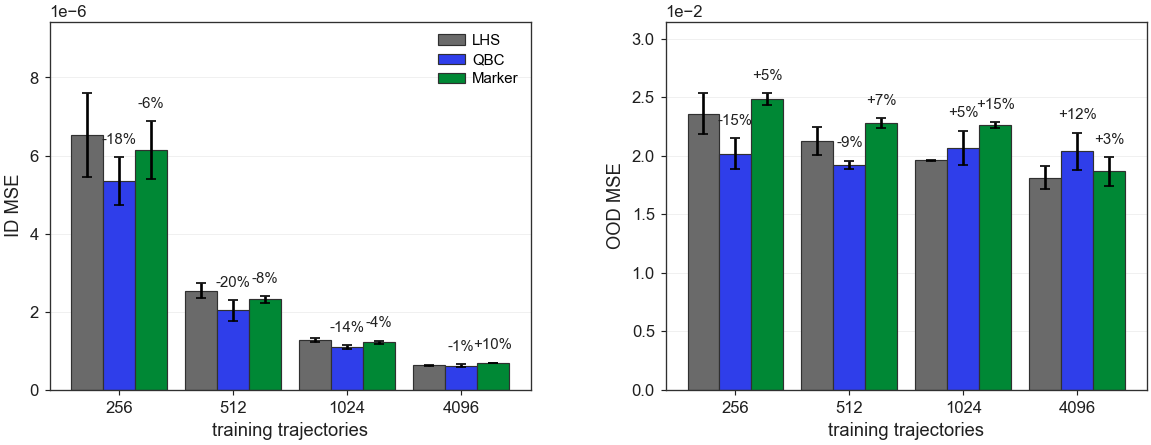

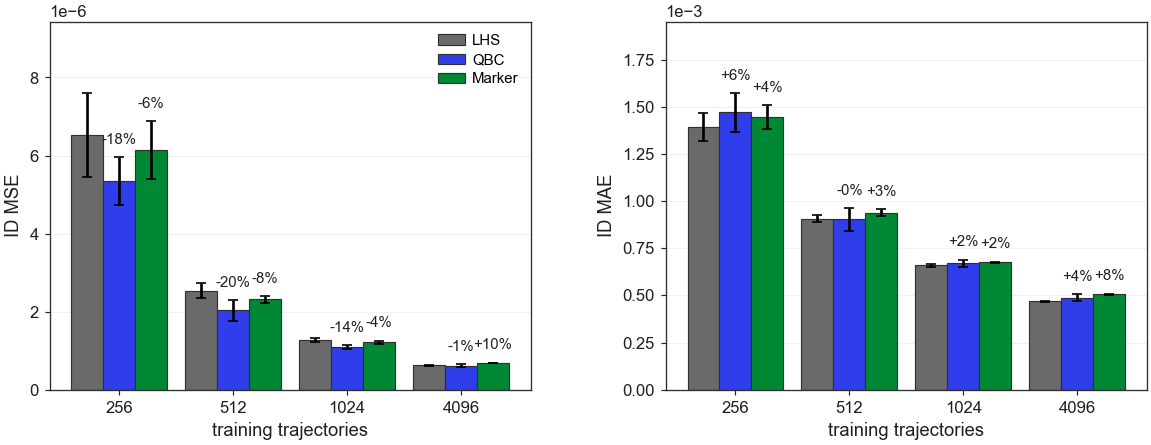

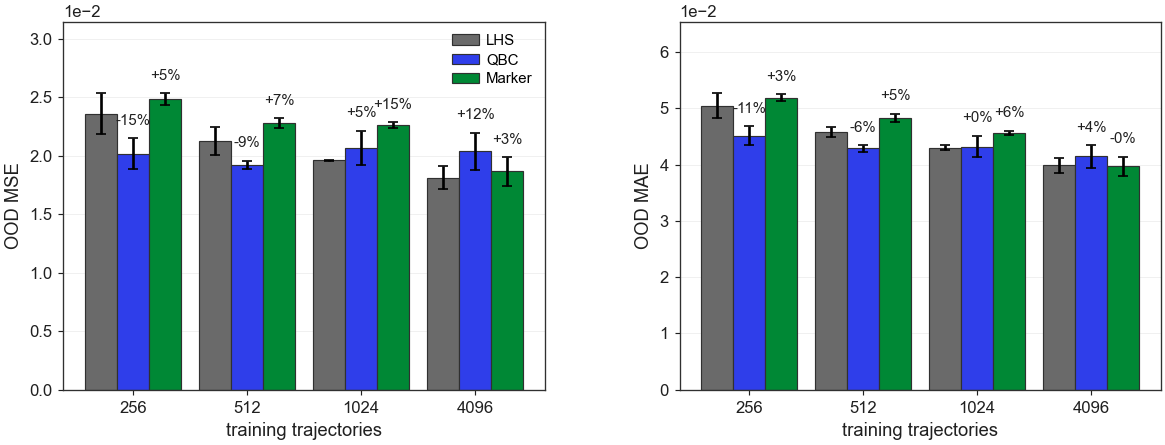

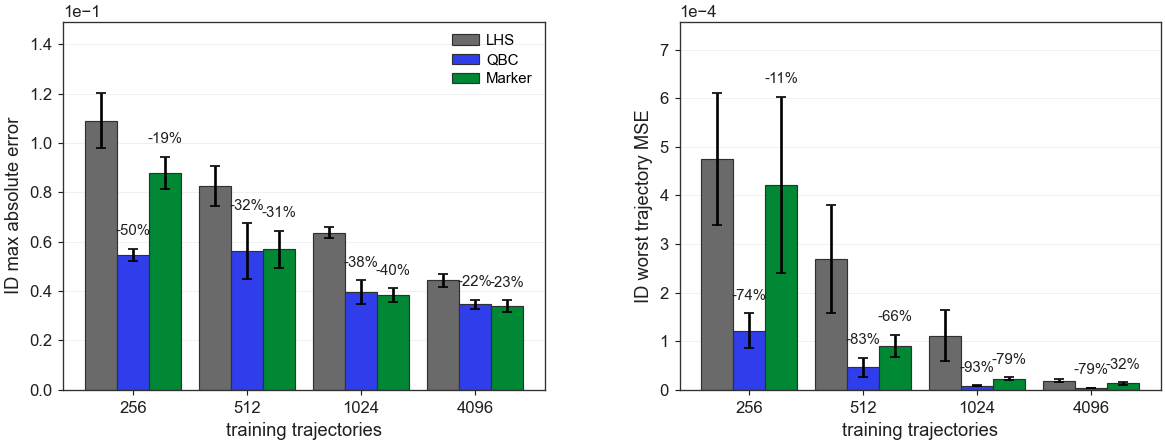

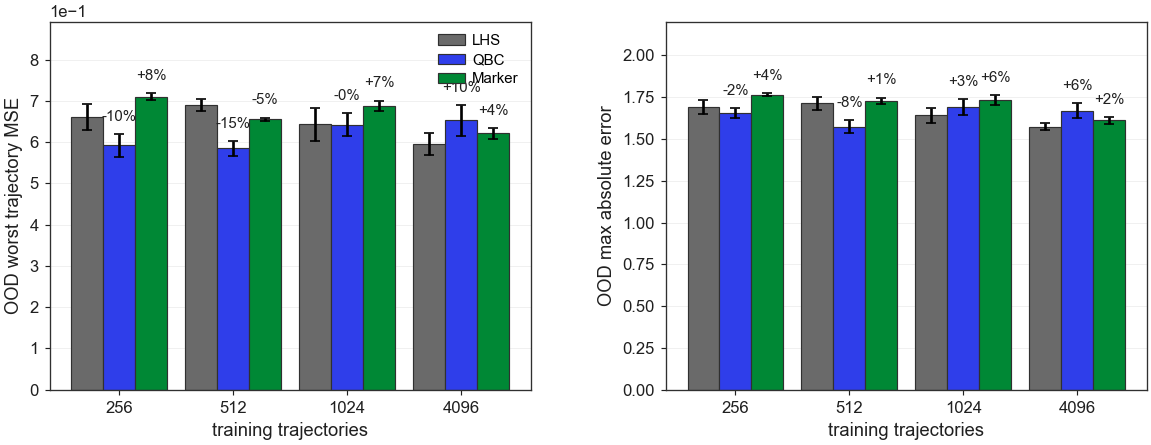

In [9]:
def metric_by_dataset(frame: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    return frame.groupby(["method", "budget", "ds"], observed=True).agg(**{metric: (metric, "mean") for metric in metrics}).reset_index()


def metric_summary(frame: pd.DataFrame, metric: str) -> pd.DataFrame:
    out = aggregate_mean_sem(
        frame,
        group_cols=["budget", "method"],
        metrics=[metric],
        seed_col="ds",
        run_col=None,
    )
    out["method"] = pd.Categorical(out["method"], categories=METHODS, ordered=True)
    out["budget"] = pd.Categorical(out["budget"], categories=BUDGETS, ordered=True)
    return out.sort_values(["budget", "method"]).reset_index(drop=True)


def plot_budget_metric(ax, metric: str, ylabel: str, *, show_legend: bool = False) -> None:
    per_ds = metric_by_dataset(perf, [metric])
    summary = metric_summary(per_ds, metric)
    baseline = summary[summary["method"] == "lhs_static"].set_index("budget")[f"{metric}_mean"]

    x = np.arange(len(BUDGETS))
    width = 0.28
    offsets = np.array([-width, 0.0, width])
    max_height = 0.0

    for offset, method in zip(offsets, METHODS):
        sub = summary[summary["method"] == method].set_index("budget").reindex(BUDGETS)
        means = sub[f"{metric}_mean"].to_numpy(dtype=float)
        errs = np.nan_to_num(sub[f"{metric}_sem"].to_numpy(dtype=float), nan=0.0)
        max_height = max(max_height, np.nanmax(means + errs))
        bars = ax.bar(
            x + offset,
            means,
            width=width,
            yerr=errs,
            capsize=3,
            color=METHOD_COLOR[method],
            edgecolor=NEUTRAL_COLORS["axis"],
            linewidth=0.7,
            label=METHOD_LABEL[method],
        )
        for bar, budget, value, err in zip(bars, BUDGETS, means, errs):
            if method == "lhs_static":
                continue
            base_value = baseline.get(budget, np.nan)
            if not np.isfinite(base_value) or not np.isfinite(value) or base_value == 0:
                continue
            delta = 100 * (value - base_value) / base_value
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + err + 0.035 * max_height,
                f"{delta:+.0f}%",
                ha="center",
                va="bottom",
                fontsize=9,
                color=NEUTRAL_COLORS["text"],
            )

    ax.set_xticks(x)
    ax.set_xticklabels([budget.removeprefix("b") for budget in BUDGETS])
    ax.set_xlabel("training trajectories")
    ax.set_ylabel(ylabel)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.grid(True, axis="y", alpha=0.45)
    ax.grid(False, axis="x")
    ax.set_ylim(top=max_height * 1.24)
    if show_legend:
        ax.legend(loc="best")


def plot_eval_metric_pair(eval_prefix: str, title: str, filename: str) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.2), sharex=True)
    plot_budget_metric(
        axes[0],
        f"best_{eval_prefix}_eval_mse",
        f"{title} MSE",
        show_legend=True,
    )
    plot_budget_metric(
        axes[1],
        f"best_{eval_prefix}_eval_mae",
        f"{title} MAE",
        show_legend=False,
    )
    fig.subplots_adjust(top=0.84, wspace=0.28)
    # Figure export disabled for repository submission; keep plot inline.
    # fig.savefig(EXPORT / filename, dpi=300, bbox_inches="tight")
    plt.show()


fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.2), sharex=True)
plot_budget_metric(
    axes[0],
    "best_id_eval_mse",
    "ID MSE",
    show_legend=True,
)
plot_budget_metric(
    axes[1],
    "best_ood_eval_mse",
    "OOD MSE",
    show_legend=False,
)
fig.subplots_adjust(top=0.84, wspace=0.28)
# Figure export disabled for repository submission; keep plot inline.
# fig.savefig(EXPORT / "dataset_generation_id_ood_mse_by_budget.png", dpi=300, bbox_inches="tight")
plt.show()

plot_eval_metric_pair("id", "ID", "dataset_generation_id_metrics_by_budget.png")
plot_eval_metric_pair("ood", "OOD", "dataset_generation_ood_metrics_by_budget.png")

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.2), sharex=True)
plot_budget_metric(
    axes[0],
    "best_id_eval_max_abs_error",
    "ID max absolute error",
    show_legend=True,
)
plot_budget_metric(
    axes[1],
    "best_id_eval_trajectory_mse_max",
    "ID worst trajectory MSE",
    show_legend=False,
)
fig.subplots_adjust(top=0.84, wspace=0.28)
# Figure export disabled for repository submission; keep plot inline.
# fig.savefig(EXPORT / "dataset_generation_id_worst_case_by_budget.png", dpi=300, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.2), sharex=True)
plot_budget_metric(
    axes[0],
    "best_ood_eval_trajectory_mse_max",
    "OOD worst trajectory MSE",
    show_legend=True,
)
plot_budget_metric(
    axes[1],
    "best_ood_eval_max_abs_error",
    "OOD max absolute error",
    show_legend=False,
)
fig.subplots_adjust(top=0.84, wspace=0.28)
# Figure export disabled for repository submission; keep plot inline.
# fig.savefig(EXPORT / "dataset_generation_ood_worst_case_by_budget.png", dpi=300, bbox_inches="tight")
plt.show()


## Runtime Breakdown


,method,budget,generation_s,preprocessing_s,training_s,training_sem,total_s,generation_overhead_vs_lhs_s,generation_as_pct_of_training
0,lhs_static,b256,13.9,4.1,1276.3,2.7,1294.3,0.0,1.1
1,lhs_static,b512,20.8,7.2,2748.2,246.7,2776.3,0.0,0.8
2,lhs_static,b1024,16.8,5.5,5015.3,10.7,5037.7,0.0,0.3
3,lhs_static,b4096,55.4,11.3,19657.2,997.7,19723.9,0.0,0.3
4,qbc_deep_ensemble,b256,32.3,4.2,1280.5,9.3,1316.9,18.4,2.5
5,qbc_deep_ensemble,b512,79.9,6.0,3371.9,2.5,3457.8,59.1,2.4
6,qbc_deep_ensemble,b1024,169.1,5.3,4434.9,26.1,4609.3,152.3,3.8
7,qbc_deep_ensemble,b4096,1797.2,11.6,22553.6,1045.2,24362.4,1741.8,8.0
8,marker_directed,b256,22.5,4.3,1343.9,17.2,1370.7,8.6,1.7
9,marker_directed,b512,29.6,4.5,2550.1,38.4,2584.2,8.8,1.2


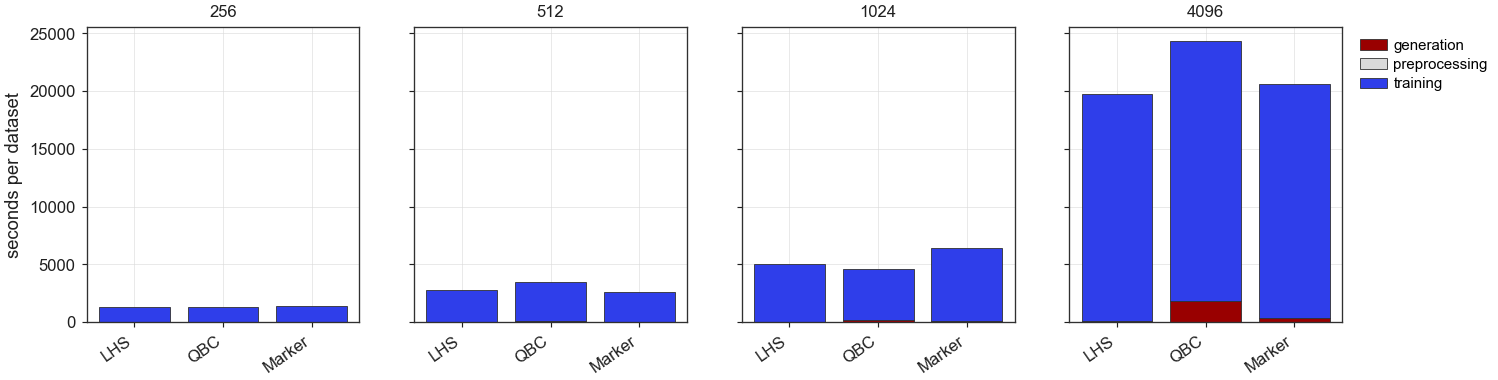

In [10]:
runtime_per_ds = (
    summary_df.groupby(["method", "budget", "ds"], observed=True)
    .agg(
        generation_s=("dataset_generation_seconds", "mean"),
        preprocessing_s=("preprocessing_seconds", "mean"),
        training_s=("baseline_training_seconds", "mean"),
    )
    .reset_index()
)
runtime_summary = (
    runtime_per_ds.groupby(["method", "budget"], observed=True)
    .agg(
        generation_s=("generation_s", "mean"),
        preprocessing_s=("preprocessing_s", "mean"),
        training_s=("training_s", "mean"),
        training_sem=("training_s", sem),
    )
    .reset_index()
)
runtime_summary["total_s"] = runtime_summary[["generation_s", "preprocessing_s", "training_s"]].sum(axis=1)
lhs_generation = runtime_summary[runtime_summary["method"] == "lhs_static"].set_index("budget")["generation_s"]
runtime_summary["generation_overhead_vs_lhs_s"] = runtime_summary["generation_s"] - runtime_summary["budget"].astype(str).map(lhs_generation)
runtime_summary["generation_as_pct_of_training"] = 100 * runtime_summary["generation_s"] / runtime_summary["training_s"]
# Scratch export disabled for repository submission; keep derived data in memory.
# runtime_summary.to_csv(EXPORT / "runtime_breakdown_numeric.csv", index=False)

display(runtime_summary.round({
    "generation_s": 1,
    "preprocessing_s": 1,
    "training_s": 1,
    "training_sem": 1,
    "total_s": 1,
    "generation_overhead_vs_lhs_s": 1,
    "generation_as_pct_of_training": 1,
}))

component_colors = {
    "generation_s": DTU_COLORS["corporate_red"],
    "preprocessing_s": DTU_COLORS["grey"],
    "training_s": DTU_COLORS["blue"],
}
component_labels = {
    "generation_s": "generation",
    "preprocessing_s": "preprocessing",
    "training_s": "training",
}

fig, axes = plt.subplots(1, len(BUDGETS), figsize=(13.5, 3.2), sharey=True)
for ax, budget in zip(axes, BUDGETS):
    sub = runtime_summary[runtime_summary["budget"] == budget].set_index("method").reindex(METHODS)
    bottom = np.zeros(len(METHODS))
    x = np.arange(len(METHODS))
    for component in ["generation_s", "preprocessing_s", "training_s"]:
        ax.bar(
            x,
            sub[component].to_numpy(dtype=float),
            bottom=bottom,
            color=component_colors[component],
            edgecolor=NEUTRAL_COLORS["axis"],
            linewidth=0.5,
            label=component_labels[component],
        )
        bottom += sub[component].to_numpy(dtype=float)
    ax.set_title(budget.removeprefix("b"))
    ax.set_xticks(x)
    ax.set_xticklabels([METHOD_LABEL[method] for method in METHODS], rotation=35, ha="right")
axes[0].set_ylabel("seconds per dataset")
axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
# Figure export disabled for repository submission; keep plot inline.
plt.show()
# save_and_show(fig, EXPORT, "dataset_generation_runtime_breakdown.png")


## Accuracy-Cost Tradeoff

Adaptive methods are compared against LHS at the same budget. Negative ID-MSE deltas indicate lower error than LHS.


,budget,method,ID MSE,delta ID MSE vs LHS,extra generation [s],extra total [s],ID MSE improvement / extra gen s
1,256,QBC,5.35e-06 +/- 6.16e-07,-18.1%,+18.4,+22.6,+0.98
2,256,Marker,6.13e-06 +/- 7.45e-07,-6.1%,+8.6,+76.4,+0.71
4,512,QBC,2.03e-06 +/- 2.69e-07,-19.7%,+59.1,+681.5,+0.33
5,512,Marker,2.32e-06 +/- 8.12e-08,-8.5%,+8.8,-192.0,+0.96
7,1024,QBC,1.09e-06 +/- 5.06e-08,-14.4%,+152.3,-428.4,+0.09
8,1024,Marker,1.22e-06 +/- 3.65e-08,-4.2%,+50.6,+1427.6,+0.08
10,4096,QBC,6.12e-07 +/- 3.53e-08,-1.5%,+1741.8,+4638.5,+0.00
11,4096,Marker,6.83e-07 +/- 8.28e-09,+9.9%,+293.9,+912.6,-0.03


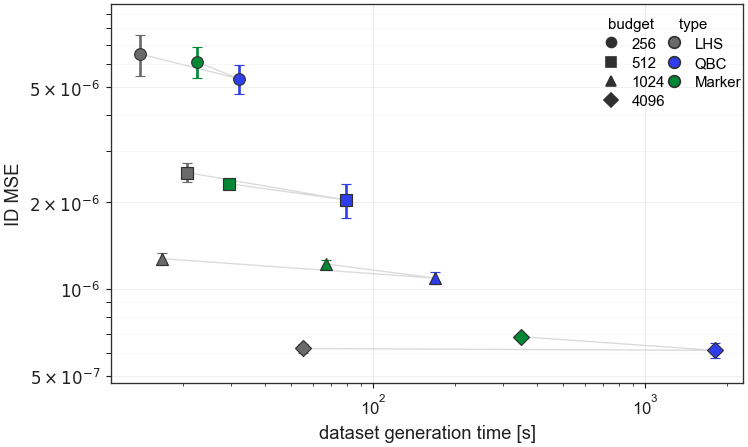

In [11]:
from matplotlib.ticker import FixedLocator, FuncFormatter, LogLocator, NullFormatter

tradeoff_summary = thesis_table_numeric.rename(columns={
    "id_mse_mean": "id_mse_mean",
    "id_mse_sem": "id_mse_sem",
    "generation_time_s_mean": "generation_time_s_mean",
    "generation_time_s_sem": "generation_time_s_sem",
    "total_time_s_mean": "total_time_s_mean",
    "total_time_s_sem": "total_time_s_sem",
}).copy()

lhs = (
    tradeoff_summary[tradeoff_summary["method"] == "lhs_static"]
    [["budget", "id_mse_mean", "generation_time_s_mean", "total_time_s_mean"]]
    .rename(columns={
        "id_mse_mean": "lhs_id_mse_mean",
        "generation_time_s_mean": "lhs_generation_time_s_mean",
        "total_time_s_mean": "lhs_total_time_s_mean",
    })
)
tradeoff_relative = tradeoff_summary.merge(lhs, on="budget", how="left")
tradeoff_relative["id_mse_delta_pct_vs_lhs"] = 100 * (
    tradeoff_relative["id_mse_mean"] - tradeoff_relative["lhs_id_mse_mean"]
) / tradeoff_relative["lhs_id_mse_mean"]
tradeoff_relative["id_mse_improvement_pct_vs_lhs"] = -tradeoff_relative["id_mse_delta_pct_vs_lhs"]
tradeoff_relative["extra_generation_time_s"] = tradeoff_relative["generation_time_s_mean"] - tradeoff_relative["lhs_generation_time_s_mean"]
tradeoff_relative["extra_total_time_s"] = tradeoff_relative["total_time_s_mean"] - tradeoff_relative["lhs_total_time_s_mean"]
tradeoff_relative["id_mse_improvement_pct_per_extra_generation_s"] = np.where(
    tradeoff_relative["extra_generation_time_s"] > 0,
    tradeoff_relative["id_mse_improvement_pct_vs_lhs"] / tradeoff_relative["extra_generation_time_s"],
    np.nan,
)
tradeoff_relative["method_label"] = tradeoff_relative["method"].map(METHOD_LABEL).astype(str)
# Scratch export disabled for repository submission; keep derived data in memory.
# tradeoff_relative.to_csv(EXPORT / "accuracy_cost_tradeoff_numeric.csv", index=False)

adaptive_tradeoff = tradeoff_relative[tradeoff_relative["method"] != "lhs_static"].copy()
adaptive_tradeoff_display = pd.DataFrame({
    "budget": adaptive_tradeoff["budget"].astype(str).str.removeprefix("b"),
    "method": adaptive_tradeoff["method"].map(METHOD_LABEL).astype(str),
    "ID MSE": adaptive_tradeoff.apply(lambda row: mean_sem_text(row, "id_mse", decimals=2), axis=1),
    "delta ID MSE vs LHS": adaptive_tradeoff["id_mse_delta_pct_vs_lhs"].map(lambda value: format_signed(value, 1, "%")),
    "extra generation [s]": adaptive_tradeoff["extra_generation_time_s"].map(lambda value: format_signed(value, 1)),
    "extra total [s]": adaptive_tradeoff["extra_total_time_s"].map(lambda value: format_signed(value, 1)),
    "ID MSE improvement / extra gen s": adaptive_tradeoff["id_mse_improvement_pct_per_extra_generation_s"].map(lambda value: format_signed(value, 2)),
})
# Scratch export disabled for repository submission; keep derived data in memory.
# adaptive_tradeoff_display.to_csv(EXPORT / "accuracy_cost_tradeoff_table.csv", index=False)
display(adaptive_tradeoff_display)

fig, ax = plt.subplots(figsize=(6.8, 4.1))
markers = {"b256": "o", "b512": "s", "b1024": "^", "b4096": "D"}
for method in METHODS:
    for budget in BUDGETS:
        row = tradeoff_summary[(tradeoff_summary["method"] == method) & (tradeoff_summary["budget"] == budget)]
        if row.empty:
            continue
        point = row.iloc[0]
        ax.errorbar(
            point["generation_time_s_mean"],
            point["id_mse_mean"],
            yerr=point["id_mse_sem"],
            fmt=markers[budget],
            color=METHOD_COLOR[method],
            markeredgecolor=NEUTRAL_COLORS["axis"],
            markeredgewidth=0.7,
            markersize=7,
            capsize=3,
        )

for budget in BUDGETS:
    sub = tradeoff_summary[tradeoff_summary["budget"] == budget].set_index("method")
    if set(METHODS).issubset(sub.index):
        ax.plot(
            sub.loc[METHODS, "generation_time_s_mean"],
            sub.loc[METHODS, "id_mse_mean"],
            color=NEUTRAL_COLORS["grid"],
            linewidth=0.8,
            zorder=0,
        )

method_handles = [
    plt.Line2D([0], [0], marker="o", color="w", label=METHOD_LABEL[method],
               markerfacecolor=METHOD_COLOR[method], markeredgecolor=NEUTRAL_COLORS["axis"], markersize=7)
    for method in METHODS
]
budget_handles = [
    plt.Line2D([0], [0], marker=markers[budget], color=NEUTRAL_COLORS["axis"], label=budget.removeprefix("b"),
               linestyle="None", markersize=6)
    for budget in BUDGETS
]
ax.set_xlabel("dataset generation time [s]")
ax.set_ylabel("ID MSE")
legend_methods = ax.legend(
    handles=method_handles,
    title="type    ",
    loc="upper left",
    bbox_to_anchor=(0.86, 0.98),
    borderaxespad=0.0,
)
ax.add_artist(legend_methods)
ax.set_yscale("log")
ax.set_xscale("log")
y_values = pd.to_numeric(tradeoff_summary["id_mse_mean"], errors="coerce").to_numpy(dtype=float)
y_errors = pd.to_numeric(tradeoff_summary["id_mse_sem"], errors="coerce").fillna(0.0).to_numpy(dtype=float)
finite = np.isfinite(y_values) & (y_values > 0)
if finite.any():
    lower = max(np.nanmin(y_values[finite] - y_errors[finite]) * 0.82, np.nanmin(y_values[finite]) * 0.65)
    upper = np.nanmax(y_values[finite] + y_errors[finite]) * 1.28
    ax.set_ylim(lower, upper)

major_ticks = []
if finite.any():
    tick_min = int(np.floor(np.log10(lower)))
    tick_max = int(np.ceil(np.log10(upper)))
    for exponent in range(tick_min, tick_max + 1):
        for multiplier in (1, 2, 5):
            tick = multiplier * 10.0 ** exponent
            if lower <= tick <= upper:
                major_ticks.append(tick)

def sci_tick(value, _position):
    if value <= 0:
        return ""
    exponent = int(np.floor(np.log10(value)))
    multiplier = value / (10.0 ** exponent)
    if np.isclose(multiplier, 1.0):
        return rf"$10^{{{exponent}}}$"
    return f"${multiplier:.0f} \\times 10^{{{exponent}}}$"

ax.yaxis.set_major_locator(FixedLocator(major_ticks))
ax.yaxis.set_major_formatter(FuncFormatter(sci_tick))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=(3.0, 4.0, 6.0, 7.0, 8.0, 9.0), numticks=50))
ax.yaxis.set_minor_formatter(NullFormatter())
ax.tick_params(axis="y", which="minor", length=3.0, width=0.6)
ax.grid(True, which="major", axis="y", alpha=0.45)
ax.grid(True, which="minor", axis="y", color=NEUTRAL_COLORS["light_grid"], linewidth=0.35, alpha=0.55)
ax.legend(
    handles=budget_handles,
    title="budget",
    loc="upper left",
    bbox_to_anchor=(0.76, 0.98),
    borderaxespad=0.0,
)
# Figure export disabled for repository submission; keep plot inline.
# fig.savefig(EXPORT / "accuracy_cost_tradeoff_id_mse_vs_generation_time.png", dpi=300, bbox_inches="tight")
plt.show()


## Adaptive Mechanisms


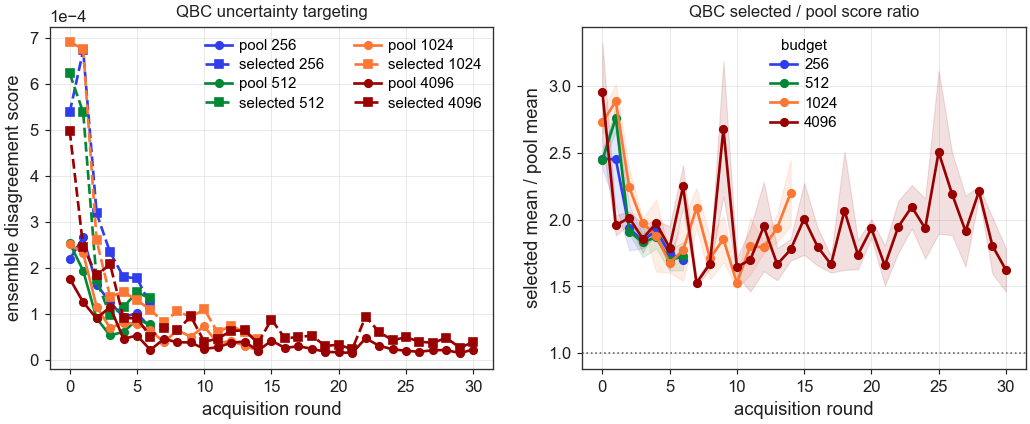

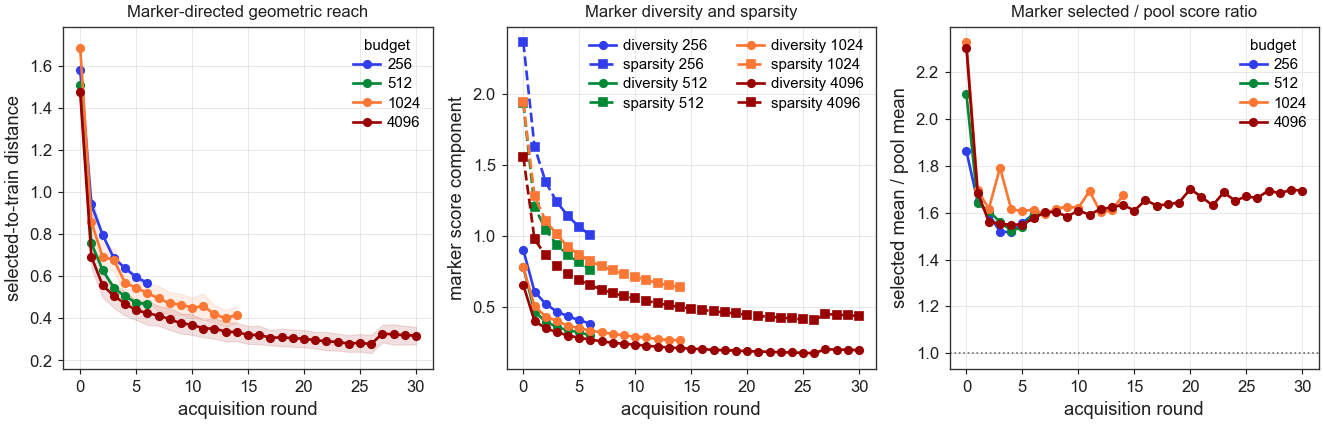

In [12]:
if adaptive.empty:
    print("No adaptive telemetry available.")
else:
    telemetry = adaptive.copy()
    telemetry["score_ratio"] = telemetry["selected_mean_score"] / telemetry["mean_score"]
    telemetry["score_ratio"] = telemetry["score_ratio"].replace([np.inf, -np.inf], np.nan)

    qbc = telemetry[telemetry["method"] == "qbc_deep_ensemble"].copy()
    qbc_round = aggregate_mean_sem(
        qbc,
        group_cols=["budget", "round_idx"],
        metrics=["mean_score", "selected_mean_score", "mean_disagreement", "score_ratio"],
        seed_col="ds",
        run_col=None,
    )
    qbc_round["budget"] = pd.Categorical(qbc_round["budget"], categories=BUDGETS, ordered=True)
    qbc_round = qbc_round.sort_values(["budget", "round_idx"]).reset_index(drop=True)
    # Scratch export disabled for repository submission; keep derived data in memory.
    # qbc_round.to_csv(EXPORT / "qbc_mechanism_rounds.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.7))
    for budget in BUDGETS:
        sub = qbc_round[qbc_round["budget"] == budget]
        color = BUDGET_COLOR[budget]
        label = budget.removeprefix("b")
        axes[0].plot(sub["round_idx"], sub["mean_score_mean"], marker="o", color=color, label=f"pool {label}")
        axes[0].plot(sub["round_idx"], sub["selected_mean_score_mean"], marker="s", linestyle="--", color=color, label=f"selected {label}")
        axes[1].plot(sub["round_idx"], sub["score_ratio_mean"], marker="o", color=color, label=label)
        axes[1].fill_between(
            sub["round_idx"].to_numpy(),
            (sub["score_ratio_mean"] - sub["score_ratio_sem"]).to_numpy(),
            (sub["score_ratio_mean"] + sub["score_ratio_sem"]).to_numpy(),
            color=color,
            alpha=0.12,
        )

    axes[0].set_title("QBC uncertainty targeting")
    axes[0].set_xlabel("acquisition round")
    axes[0].set_ylabel("ensemble disagreement score")
    axes[0].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    axes[0].legend(ncol=2)
    axes[1].axhline(1.0, color=NEUTRAL_COLORS["muted"], linewidth=1.0, linestyle=":")
    axes[1].set_title("QBC selected / pool score ratio")
    axes[1].set_xlabel("acquisition round")
    axes[1].set_ylabel("selected mean / pool mean")
    axes[1].legend(title="budget")
    # Figure export disabled for repository submission; keep plot inline.
    plt.show()
    # save_and_show(fig, EXPORT, "qbc_mechanism_uncertainty_targeting.png")

    marker = telemetry[telemetry["method"] == "marker_directed"].copy()
    marker_round = aggregate_mean_sem(
        marker,
        group_cols=["budget", "round_idx"],
        metrics=[
            "mean_selected_to_train_distance",
            "mean_marker_diversity",
            "mean_marker_sparsity",
            "mean_score",
            "selected_mean_score",
            "score_ratio",
        ],
        seed_col="ds",
        run_col=None,
    )
    marker_round["budget"] = pd.Categorical(marker_round["budget"], categories=BUDGETS, ordered=True)
    marker_round = marker_round.sort_values(["budget", "round_idx"]).reset_index(drop=True)
    # Scratch export disabled for repository submission; keep derived data in memory.
    # marker_round.to_csv(EXPORT / "marker_directed_mechanism_rounds.csv", index=False)

    fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.7))
    for budget in BUDGETS:
        sub = marker_round[marker_round["budget"] == budget]
        color = BUDGET_COLOR[budget]
        label = budget.removeprefix("b")
        axes[0].plot(sub["round_idx"], sub["mean_selected_to_train_distance_mean"], marker="o", color=color, label=label)
        axes[0].fill_between(
            sub["round_idx"].to_numpy(),
            (sub["mean_selected_to_train_distance_mean"] - sub["mean_selected_to_train_distance_sem"]).to_numpy(),
            (sub["mean_selected_to_train_distance_mean"] + sub["mean_selected_to_train_distance_sem"]).to_numpy(),
            color=color,
            alpha=0.12,
        )
        axes[1].plot(sub["round_idx"], sub["mean_marker_diversity_mean"], marker="o", color=color, label=f"diversity {label}")
        axes[1].plot(sub["round_idx"], sub["mean_marker_sparsity_mean"], marker="s", linestyle="--", color=color, label=f"sparsity {label}")
        axes[2].plot(sub["round_idx"], sub["score_ratio_mean"], marker="o", color=color, label=label)

    axes[0].set_title("Marker-directed geometric reach")
    axes[0].set_xlabel("acquisition round")
    axes[0].set_ylabel("selected-to-train distance")
    axes[0].legend(title="budget")
    axes[1].set_title("Marker diversity and sparsity")
    axes[1].set_xlabel("acquisition round")
    axes[1].set_ylabel("marker score component")
    axes[1].legend(ncol=2)
    axes[2].axhline(1.0, color=NEUTRAL_COLORS["muted"], linewidth=1.0, linestyle=":")
    axes[2].set_title("Marker selected / pool score ratio")
    axes[2].set_xlabel("acquisition round")
    axes[2].set_ylabel("selected mean / pool mean")
    axes[2].legend(title="budget")
    # Figure export disabled for repository submission; keep plot inline.
    plt.show()
    # save_and_show(fig, EXPORT, "marker_directed_mechanism_targeting.png")


In [13]:
def first_last_summary(frame: pd.DataFrame, signal_col: str, signal_label: str) -> pd.DataFrame:
    rows = []
    for (method, budget, ds), group in frame.groupby(["method", "budget", "ds"], observed=True):
        group = group.sort_values("round_idx")
        first = group.iloc[0]
        last = group.iloc[-1]
        rows.append({
            "method": method,
            "budget": budget,
            "ds": ds,
            "rounds": len(group),
            "initial_train_size": first["train_size_before"],
            "final_train_size": last["train_size_before"] + last["selected_count"],
            "selected_total": group["selected_count"].sum(),
            "score_ratio_first": first["score_ratio"],
            "score_ratio_last": last["score_ratio"],
            f"{signal_label}_first": first[signal_col],
            f"{signal_label}_last": last[signal_col],
        })
    out = pd.DataFrame(rows)
    out[f"{signal_label}_change_pct"] = 100 * (out[f"{signal_label}_last"] - out[f"{signal_label}_first"]) / out[f"{signal_label}_first"]
    return out

if adaptive.empty:
    print("No adaptive telemetry available.")
else:
    telemetry = adaptive.copy()
    telemetry["score_ratio"] = telemetry["selected_mean_score"] / telemetry["mean_score"]
    telemetry["score_ratio"] = telemetry["score_ratio"].replace([np.inf, -np.inf], np.nan)

    qbc_summary_ds = first_last_summary(
        telemetry[telemetry["method"] == "qbc_deep_ensemble"],
        "mean_disagreement",
        "pool_disagreement",
    )
    marker_summary_ds = first_last_summary(
        telemetry[telemetry["method"] == "marker_directed"],
        "mean_selected_to_train_distance",
        "selected_to_train_distance",
    )
    mechanism_summary_ds = pd.concat([qbc_summary_ds, marker_summary_ds], ignore_index=True)
    # Scratch export disabled for repository submission; keep derived data in memory.
    # mechanism_summary_ds.to_csv(EXPORT / "adaptive_mechanism_summary_by_dataset.csv", index=False)

    summary_rows = []
    for (method, budget), group in mechanism_summary_ds.groupby(["method", "budget"], observed=True):
        row = {
            "method": method,
            "budget": budget,
            "rounds": group["rounds"].mean(),
            "initial train": group["initial_train_size"].mean(),
            "final train": group["final_train_size"].mean(),
            "score ratio first": group["score_ratio_first"].mean(),
            "score ratio last": group["score_ratio_last"].mean(),
        }
        if method == "qbc_deep_ensemble":
            row["mechanism signal"] = "pool disagreement"
            row["signal first"] = group["pool_disagreement_first"].mean()
            row["signal last"] = group["pool_disagreement_last"].mean()
            row["signal change [%]"] = group["pool_disagreement_change_pct"].mean()
        else:
            row["mechanism signal"] = "selected-to-train distance"
            row["signal first"] = group["selected_to_train_distance_first"].mean()
            row["signal last"] = group["selected_to_train_distance_last"].mean()
            row["signal change [%]"] = group["selected_to_train_distance_change_pct"].mean()
        summary_rows.append(row)

    mechanism_summary = pd.DataFrame(summary_rows)
    mechanism_summary["method"] = pd.Categorical(mechanism_summary["method"], categories=METHODS, ordered=True)
    mechanism_summary["budget"] = pd.Categorical(mechanism_summary["budget"], categories=BUDGETS, ordered=True)
    mechanism_summary = mechanism_summary.sort_values(["method", "budget"]).reset_index(drop=True)
    mechanism_summary["method_label"] = mechanism_summary["method"].map(METHOD_LABEL).astype(str)
    # Scratch export disabled for repository submission; keep derived data in memory.
    # mechanism_summary.to_csv(EXPORT / "adaptive_mechanism_summary.csv", index=False)

    mechanism_display = pd.DataFrame({
        "method": mechanism_summary["method_label"],
        "budget": mechanism_summary["budget"].astype(str).str.removeprefix("b"),
        "rounds": mechanism_summary["rounds"].map(lambda value: f"{value:.0f}"),
        "train size": mechanism_summary.apply(lambda row: f"{row['initial train']:.0f} -> {row['final train']:.0f}", axis=1),
        "score ratio first -> last": mechanism_summary.apply(lambda row: f"{row['score ratio first']:.2f} -> {row['score ratio last']:.2f}", axis=1),
        "mechanism signal": mechanism_summary["mechanism signal"],
        "signal first -> last": mechanism_summary.apply(lambda row: f"{row['signal first']:.2e} -> {row['signal last']:.2e}", axis=1),
        "signal change": mechanism_summary["signal change [%]"].map(lambda value: format_signed(value, 1, "%")),
    })
    write_table(mechanism_display, "dataset_generation", name="mechanism_summary")
    display(mechanism_display)


,method,budget,rounds,train size,score ratio first -> last,mechanism signal,signal first -> last,signal change
0,QBC,256,7,32 -> 256,2.45 -> 1.70,pool disagreement,2.19e-04 -> 7.05e-05,-66.1%
1,QBC,512,7,64 -> 512,2.45 -> 1.73,pool disagreement,2.54e-04 -> 7.79e-05,-67.5%
2,QBC,1024,15,64 -> 1024,2.73 -> 2.20,pool disagreement,2.52e-04 -> 2.10e-05,-91.1%
3,QBC,4096,31,128 -> 4096,2.96 -> 1.62,pool disagreement,1.77e-04 -> 2.32e-05,-84.2%
4,Marker,256,7,32 -> 256,1.86 -> 1.59,selected-to-train distance,1.58e+00 -> 5.68e-01,-63.8%
5,Marker,512,7,64 -> 512,2.11 -> 1.60,selected-to-train distance,1.51e+00 -> 4.68e-01,-68.9%
6,Marker,1024,15,64 -> 1024,2.33 -> 1.67,selected-to-train distance,1.69e+00 -> 4.18e-01,-75.2%
7,Marker,4096,31,128 -> 4096,2.30 -> 1.69,selected-to-train distance,1.47e+00 -> 3.18e-01,-78.5%
